In [1]:
# import necessary libraries and functions and the corpus
import numpy as np
from synthics import (
    load_feynman_csv,
    extract_features,
    render_tree_svg,
    extract_production_rules,
    extract_production_rules_bayesian,
    generate_equation,
    generate_datasets,
    validate_generator
)

equations = load_feynman_csv()

## 1. Getting started
Here are examples how to use the synthics data generator. One can either generate synthetic datasets that are...
1. mimick the structure of given equations in a corpus
2. have mathetmatical structure but produce random equations based on the limits set by the user

In [2]:
# Option 1: Generate datasets based on a corpus of equations
datasets = generate_datasets(equations, n_datasets=100, n_samples_per_dataset=200)



Optimising B-PCFG hyperparameters (n_trials=100, n_gen=500)...


  0%|          | 0/100 [00:00<?, ?it/s]


  Final KS results  (alpha=44, tau=6)
  Feature                    KS stat    p-value   Result
  -------------------------------------------------------
  depth                        0.077      0.631     PASS
  n_operators                  0.126      0.104     PASS
  n_unique_variables           0.126      0.104     PASS
  n_constants                  0.130      0.086     PASS
  unary_ratio                  0.104      0.264     PASS
  avg_operator_depth           0.106      0.244     PASS
  avg_leaf_depth               0.084      0.521     PASS
  branching_factor             0.062      0.858     PASS

  8/8 features pass KS test
  Best alpha = 44
  Best tau   = 6


/Users/vepsalj1/Documents/synthics/synthics.py:1225: ComplexWarning: Casting complex values to real discards the imaginary part
  y = np.asarray(f(*args), dtype=float)


In [3]:
# Option 2: Generate datasets randomly
datasets = generate_datasets(
    n_datasets            = 50,
    n_samples_per_dataset = 200,
    uniform_ratio         = 0.5,
    tau                   = 7,
    max_depth             = 8,
    n_vars                = 3,
)

Generating 50 random datasets (tau=7, max_depth=8, n_vars=3)


## 2. Testing and Validation
In this part, there are the tests and validation reported in the paper.

In [4]:
# Load the Feynman dataset and extract features for each equation

# Extract features from the whole corpus
features = []
failed   = []
for eq in equations:
    if eq["generic"] is None:
        failed.append(eq["filename"])
        continue
    f = extract_features(eq["generic"])
    f["filename"] = eq["filename"]
    features.append(f)

print(f"Loaded {len(features)} equations, {len(failed)} failed parsing")

Loaded 100 equations, 0 failed parsing


In [5]:
# Show an example of the extracted features for the 3rd equation
features[2]

{'equation': 'sqrt(2)*exp(-(x2 - x3)**2/(2*x1**2))/(2*sqrt(pi)*x1)',
 'depth': 6,
 'n_nodes': 24,
 'n_leaves': 14,
 'n_operators': 10,
 'n_variables': 4,
 'n_unique_variables': 3,
 'n_constants': 10,
 'variable_reuse': 1,
 'operator_counts': {'Mul': 3, 'Pow': 5, 'exp': 1, 'Add': 1},
 'n_unary': 1,
 'n_binary': 9,
 'unary_ratio': 0.1,
 'binary_ratio': 0.9,
 'avg_operator_depth': 2.1,
 'avg_leaf_depth': 3.2143,
 'branching_factor': 2.3,
 'filename': 'I.6.2b'}

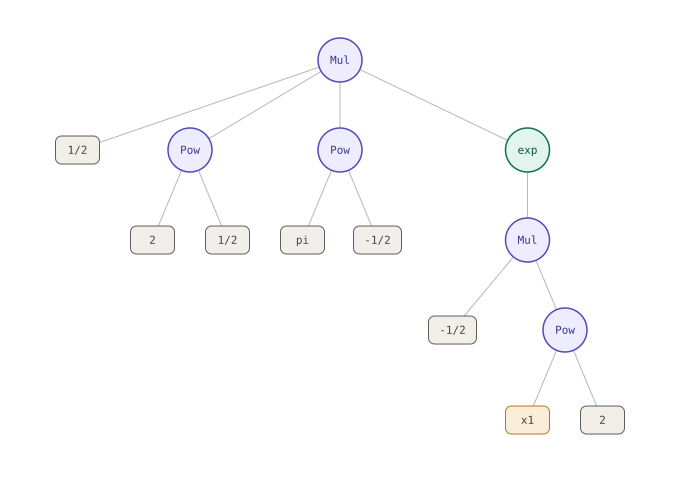

In [6]:
# render a pretty tree visualization for the 1st equation
svg = render_tree_svg(features[0]["equation"])
from IPython.display import SVG, display
display(SVG(svg))

### 2.1 Extracting PCFG
Here the PCFG is extracted. As can be seen from the validation plot, the structural propertiers resemble the ones from the corpus but do not pass most of the KS tests.

In [7]:
# Extract production rules from the corpus and print them
grammar = extract_production_rules(equations, verbose=False)

In [8]:
# generate some equations from the extracted grammar
rng       = np.random.default_rng(43)
generated = []
while len(generated) < 5:
    expr = generate_equation(grammar, tau=6.0, max_depth=10, rng=rng)
    if expr is not None:
        f = extract_features(expr)
        print(f"{str(expr):50s}  depth={f['depth']}  n_vars={f['n_unique_variables']}")
        generated.append(expr)

x1*sqrt(x2)/4                                       depth=2  n_vars=2
3*x1*x2                                             depth=1  n_vars=2
x1/(4*pi*x2*sqrt(x3))                               depth=2  n_vars=3
x1*x2*sin(x3)                                       depth=2  n_vars=3
-2*x1*x2                                            depth=1  n_vars=2



Comparing 100 corpus equations vs 1000 generated
Feature                    KS stat    p-value   Result
-------------------------------------------------------
  depth                      0.299      0.000     FAIL
  n_operators                0.381      0.000     FAIL
  n_unique_variables         0.228      0.000     FAIL
  n_constants                0.321      0.000     FAIL
  unary_ratio                0.115      0.169     PASS
  avg_operator_depth         0.350      0.000     FAIL
  avg_leaf_depth             0.342      0.000     FAIL
  branching_factor           0.111      0.200     PASS

  2/8 features pass KS test (p >= 0.05)

Operator       Corpus %  Generated %
------------------------------------
  Pow             47.1%        41.3%
  Mul             33.2%        41.9%
  Add             12.6%        10.5%
  cos              2.3%         2.3%
  exp              2.1%         1.5%
  sin              1.9%         2.3%
  arcsin           0.4%         0.0%
  log              0.2% 

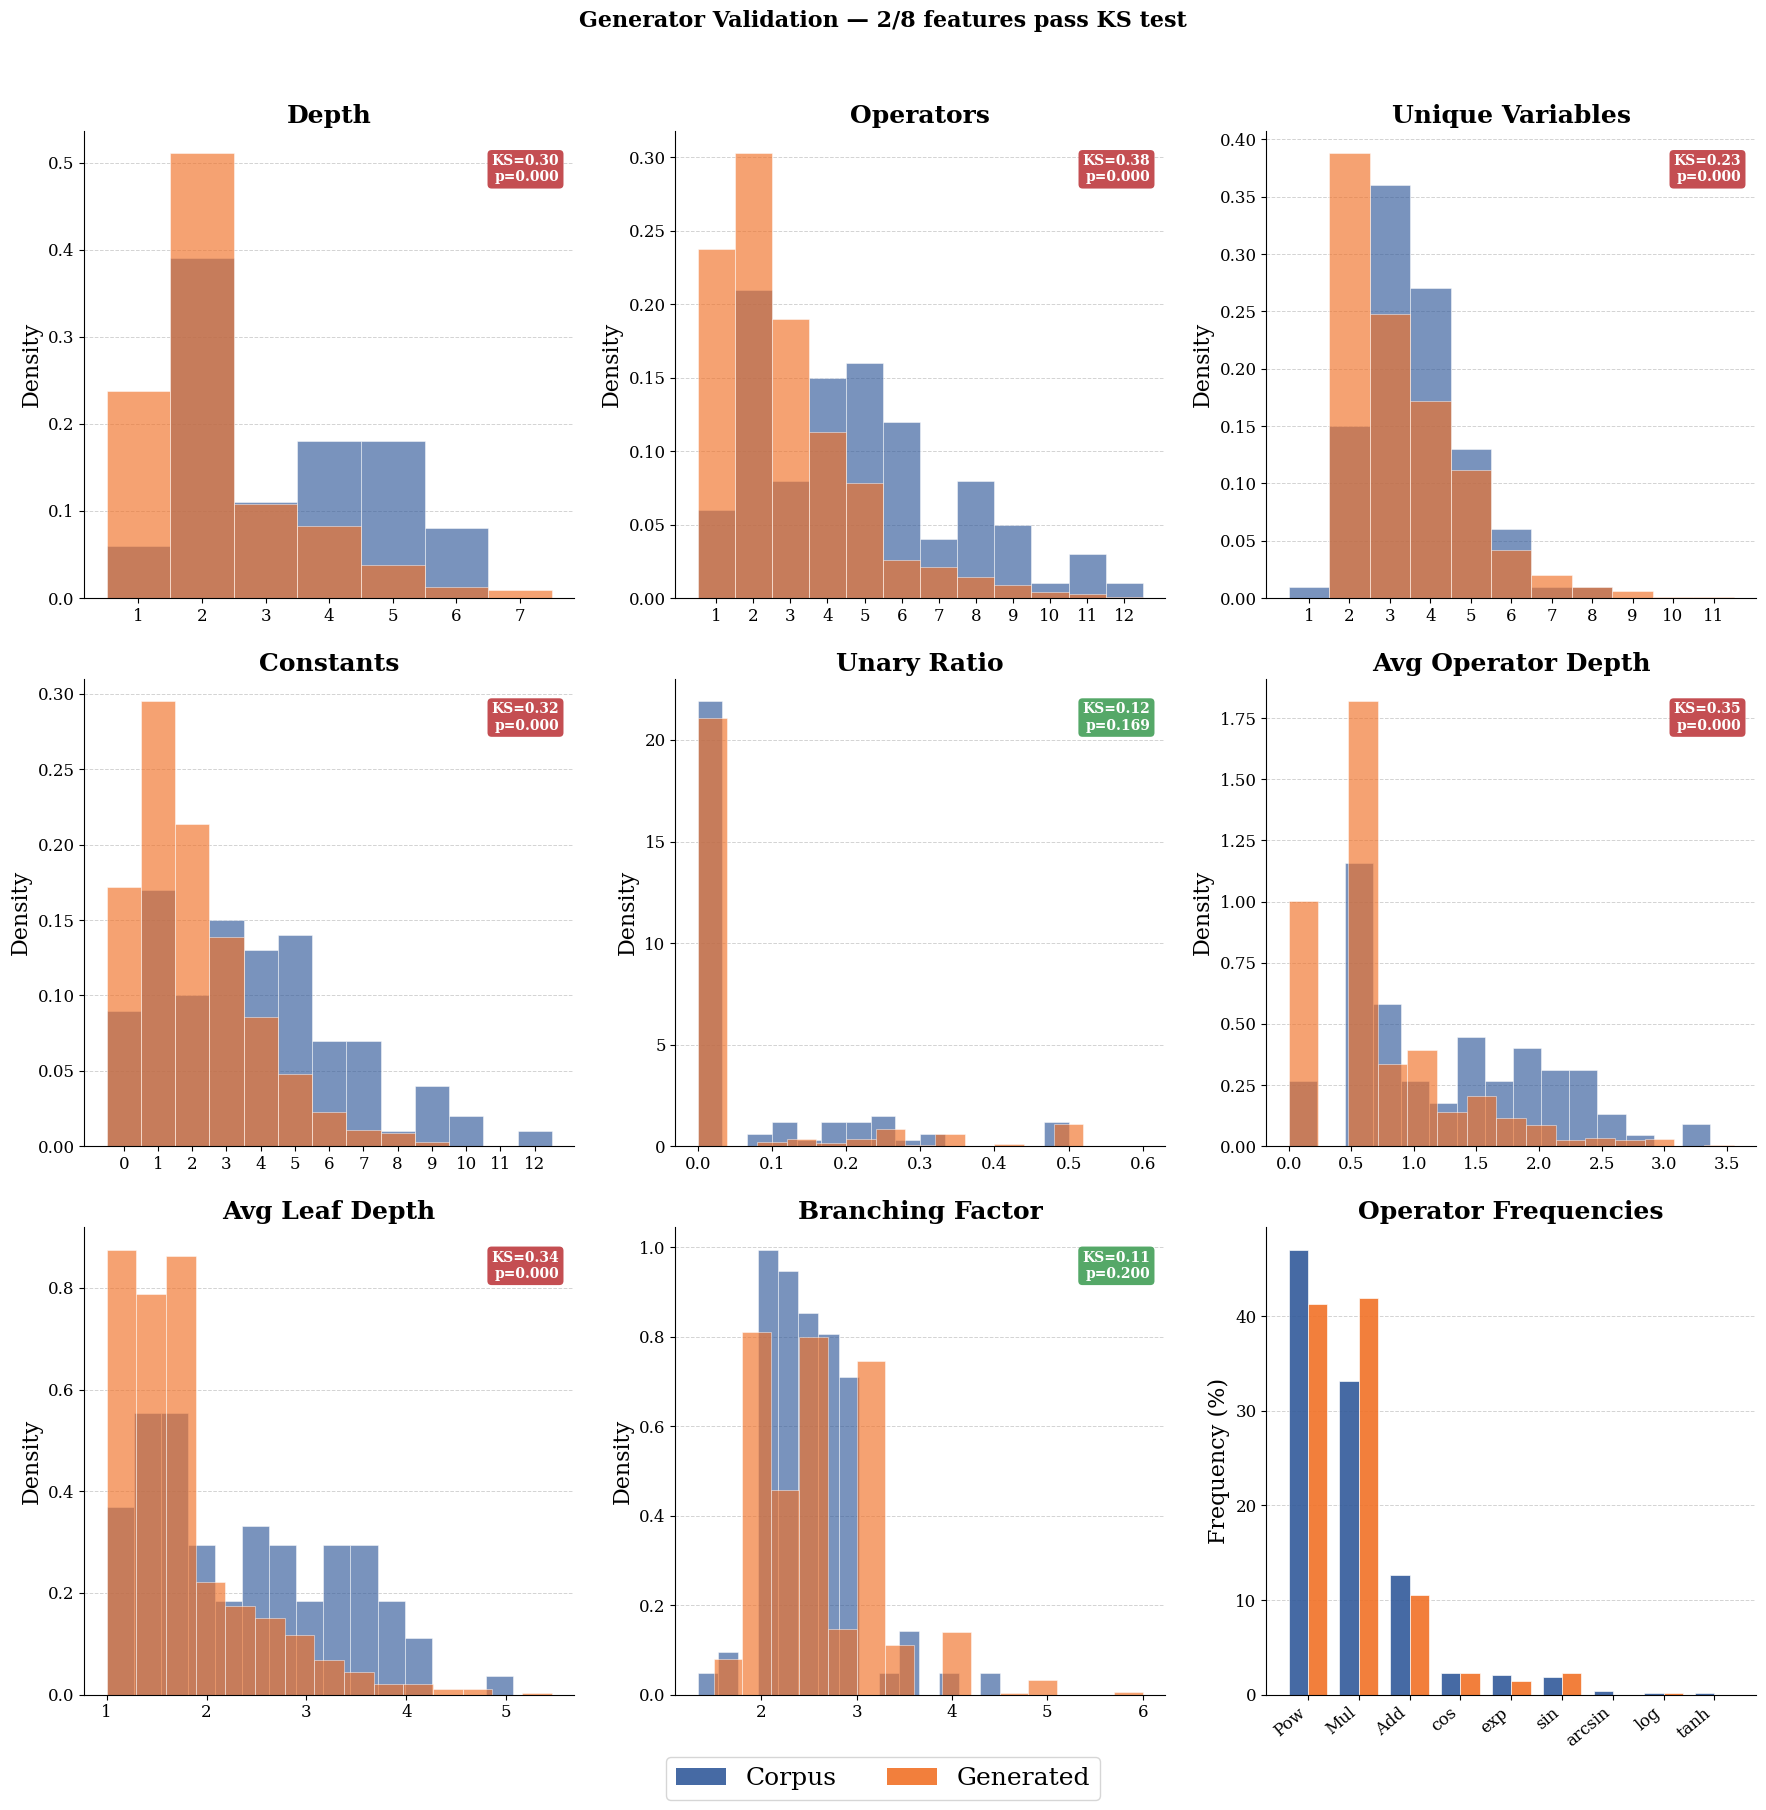

In [9]:
# Validate generator
report = validate_generator(
    grammar,
    equations,
    n_generated  = 1000,
    tau          = 6.0,
    max_depth    = 8,
    plot         = True,
    save_path    = "results/pcfg_validation.png",
    rng          = rng,
)

### 2.2 Extracting B-PCFG
Here the B-PCFG is extracted. As can be seen from the validation plot, the structural propertiers resemble the ones from the corpus and pass all of the KS tests. However, the distributions as far from identical. Nonetheless, the synthetic data generated with the B-PCFG is close enough to be used for machine learning tasks where the corpus equations would be used.

In [10]:
grammar   = extract_production_rules_bayesian(equations, alpha=19, verbose=False)


Comparing 100 corpus equations vs 1000 generated
Feature                    KS stat    p-value   Result
-------------------------------------------------------
  depth                      0.077      0.631     PASS
  n_operators                0.126      0.104     PASS
  n_unique_variables         0.126      0.104     PASS
  n_constants                0.130      0.086     PASS
  unary_ratio                0.104      0.264     PASS
  avg_operator_depth         0.106      0.244     PASS
  avg_leaf_depth             0.084      0.521     PASS
  branching_factor           0.062      0.858     PASS

  8/8 features pass KS test (p >= 0.05)

Operator       Corpus %  Generated %
------------------------------------
  Pow             47.1%        39.6%
  Mul             33.2%        31.4%
  Add             12.6%        17.9%
  cos              2.3%         4.8%
  exp              2.1%         2.7%
  sin              1.9%         3.3%
  arcsin           0.4%         0.0%
  log              0.2% 

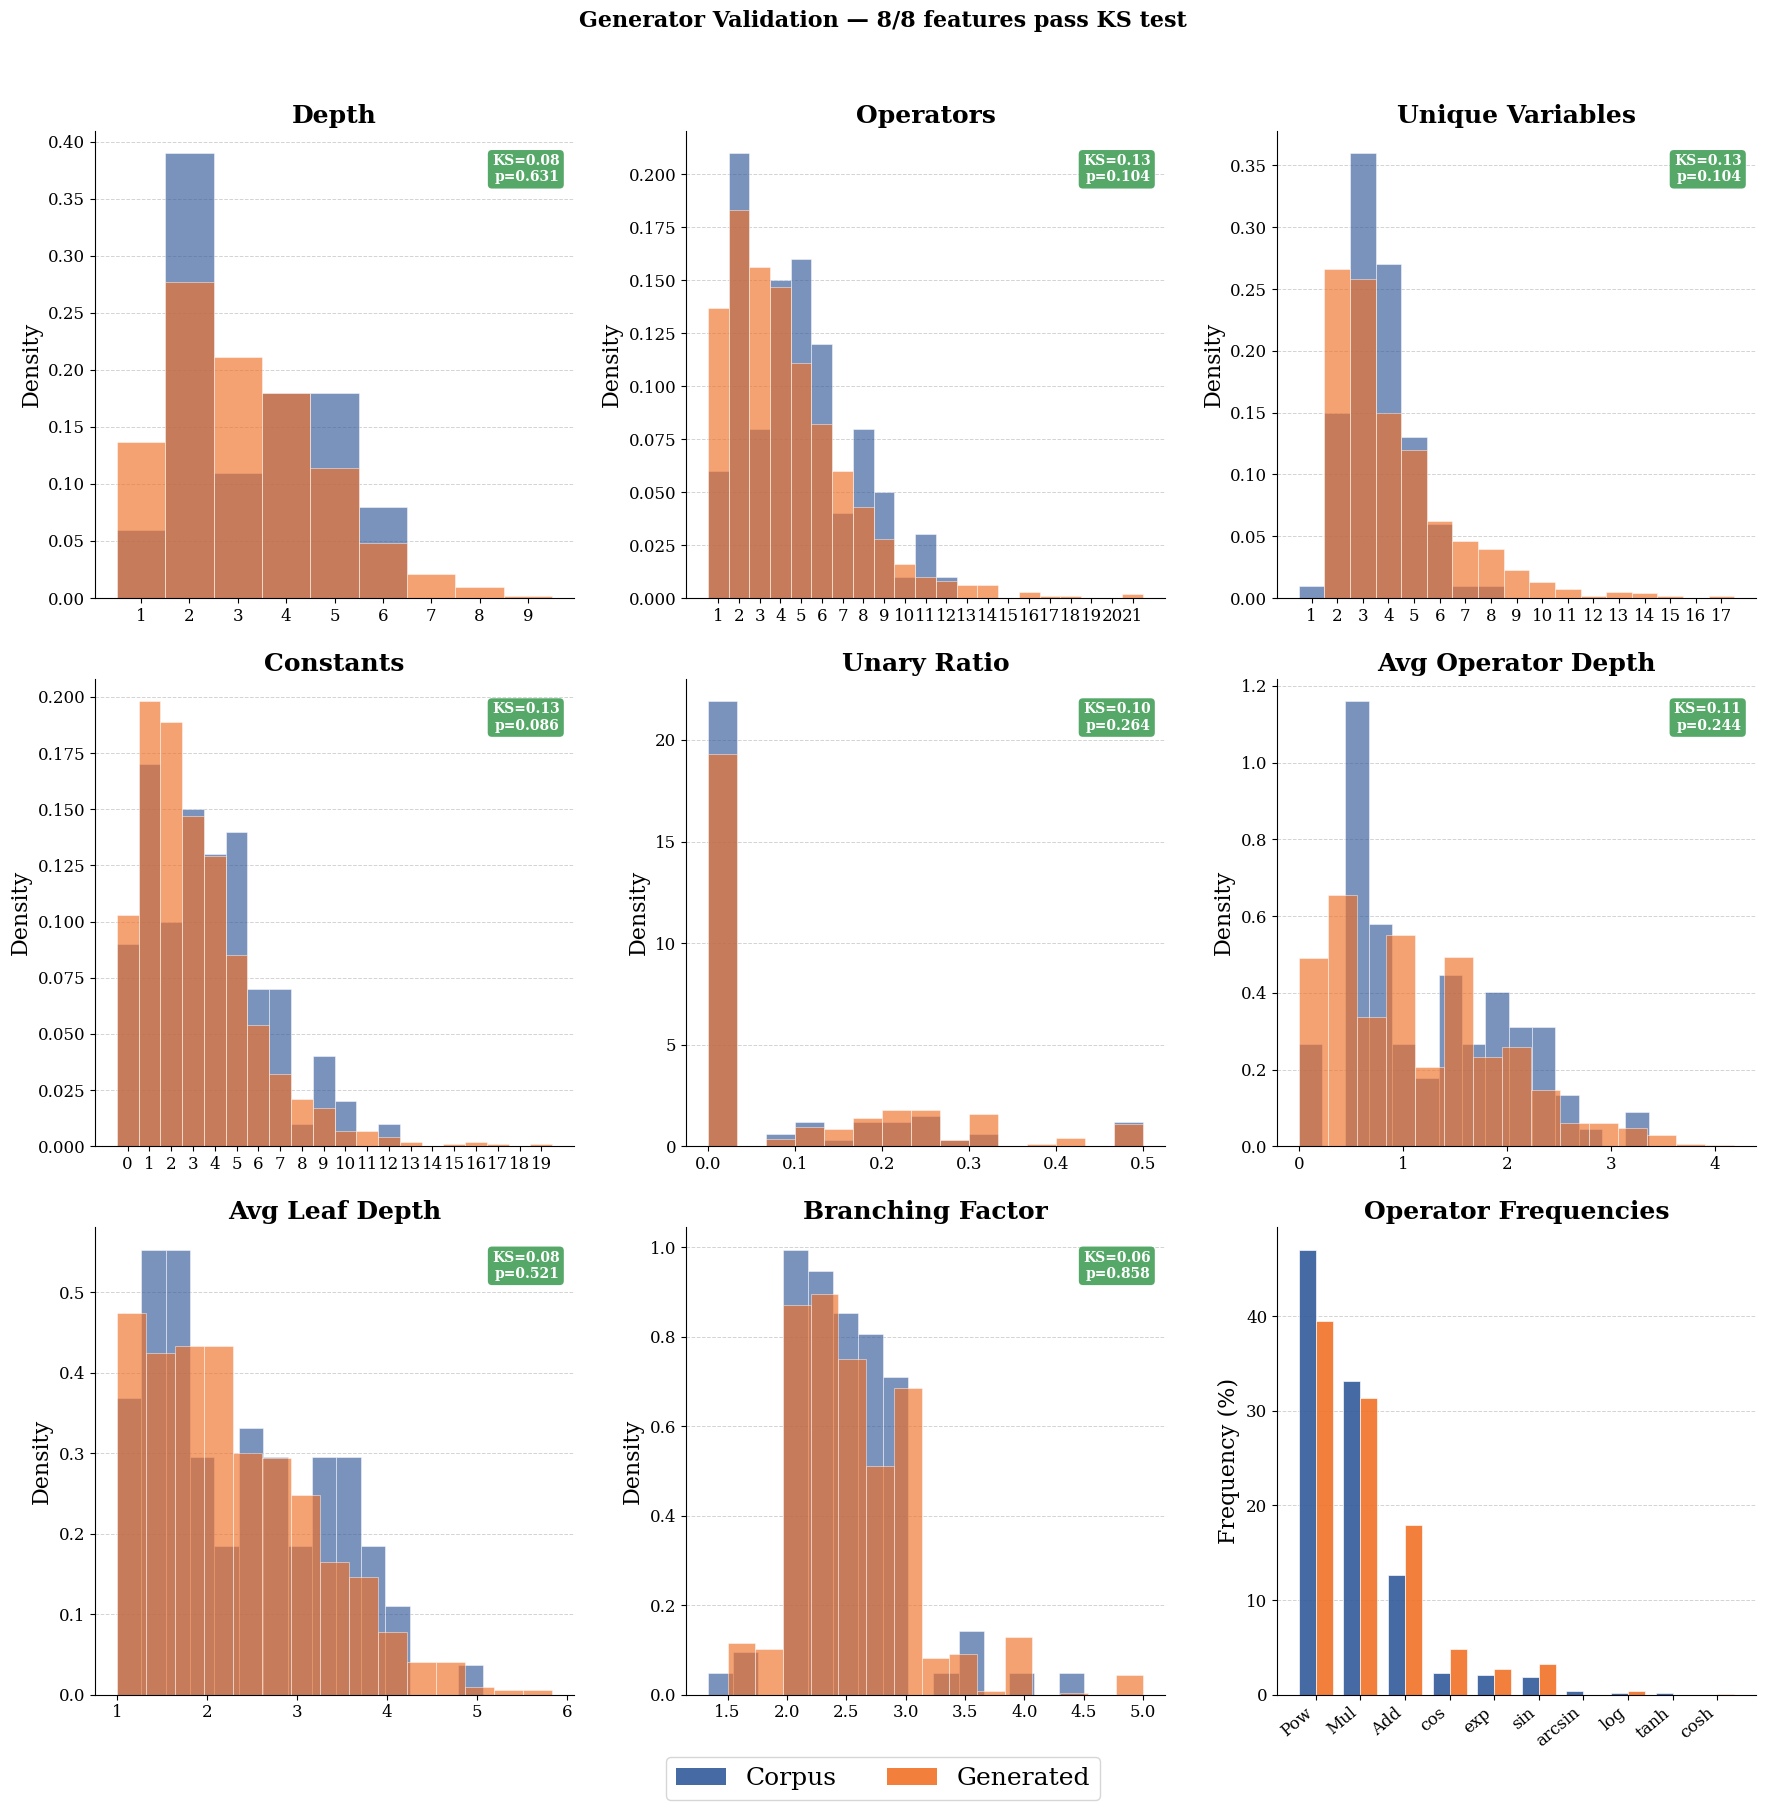

In [11]:
# Check the alpha and tau from the optimization in the beginning of the notebook
grammar   = extract_production_rules_bayesian(equations, alpha=44)
rng       = np.random.default_rng(43)

report = validate_generator(
    grammar,
    equations,
    n_generated  = 1000,
    tau          = 6,
    max_depth    = 8,
    plot         = True,
    save_path    = "results/b-pcfg_validation.png.png",
    rng          = rng,
)